# Learning Rate Experiments for Vanilla DQN

This notebook runs a learning-rate ablation study for the vanilla DQN LunarLander baseline. All baseline parameters are kept fixed except `learning_rate`.


## 1. Setup and Imports


In [1]:
import sys
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

from core.vanilla_dqn_lunar_lander import (
    train_dqn,
    evaluate_dqn,
    save_plot,
    save_results,
    save_model,
)


Using device: cpu


## 2. Experiment Settings

Keep the vanilla baseline settings unchanged and vary only the learning rate.


In [2]:
learning_rates = [3e-3, 2e-3, 1e-3, 8e-4, 7e-4, 5e-4, 3e-4, 1e-4, 5e-5]
num_episodes = 500
num_eval_episodes = 10

# ======== Multi-seed experiment setup ========
# Use the same five seeds for every learning rate so the comparison is fairer.
seeds = [0, 1, 2, 3, 4]
# ======== End multi-seed experiment setup ========

base_hyperparameters = {
    'batch_size': 32,
    'update_frequency': 4,
    'target_update_frequency': 100,
    'num_layers': 2,
    'hidden_dim': 128,
    'epsilon_decay': 0.995,
    'gamma': 0.99,
    'num_episodes': num_episodes,
    'num_eval_episodes': num_eval_episodes,
    'seeds': seeds,
}


## 3. Run Learning Rate Ablation

Each learning rate is trained, evaluated, and saved automatically under `results/ablations/learning_rate/<learning_rate>/`.


In [3]:
all_results = {}
run_records = []

print('=' * 70)
print('DQN Learning Rate Ablation Study')
print(f'Testing {len(learning_rates)} learning rates x {len(seeds)} seeds = {len(learning_rates) * len(seeds)} training runs')
print('=' * 70)

for lr in learning_rates:
    lr_variant_name = f'{lr:.0e}'
    all_results[lr_variant_name] = {
        'learning_rate': lr,
        'runs': [],
    }

    for seed in seeds:
        # ======== Multi-seed learning-rate run ========
        # Each learning rate is trained with the same seed set to reduce lucky-run bias.
        variant_name = f'{lr_variant_name}_seed_{seed}'

        print('' + '=' * 70)
        print(f'Training with learning_rate = {lr} ({lr_variant_name}), seed = {seed}')
        print('=' * 70)

        agent, rewards, losses = train_dqn(
            num_episodes=num_episodes,
            batch_size=base_hyperparameters['batch_size'],
            update_frequency=base_hyperparameters['update_frequency'],
            target_update_frequency=base_hyperparameters['target_update_frequency'],
            num_layers=base_hyperparameters['num_layers'],
            hidden_dim=base_hyperparameters['hidden_dim'],
            epsilon_decay=base_hyperparameters['epsilon_decay'],
            learning_rate=lr,
            seed=seed,
        )

        print('Evaluating trained agent...')
        eval_rewards = evaluate_dqn(agent, num_episodes=num_eval_episodes, seed=seed)

        hyperparameters = dict(base_hyperparameters)
        hyperparameters['learning_rate'] = lr
        hyperparameters['seed'] = seed

        save_results(
            agent,
            rewards,
            losses,
            hyperparameters,
            experiment_name='learning_rate',
            variant_name=variant_name,
        )
        save_model(agent, experiment_name='learning_rate', variant_name=variant_name)
        save_plot(rewards, losses, experiment_name='learning_rate', variant_name=variant_name)

        final_avg_reward = float(np.mean(rewards[-25:]))
        eval_avg_reward = float(np.mean(eval_rewards))
        best_reward = float(max(rewards))

        run_result = {
            'seed': seed,
            'train_rewards': rewards,
            'losses': losses,
            'eval_rewards': eval_rewards,
            'final_avg_reward': final_avg_reward,
            'eval_avg_reward': eval_avg_reward,
            'best_reward': best_reward,
        }
        all_results[lr_variant_name]['runs'].append(run_result)

        run_records.append({
            'variant': lr_variant_name,
            'learning_rate': lr,
            'seed': seed,
            'final_avg_reward': final_avg_reward,
            'eval_avg_reward': eval_avg_reward,
            'best_training_reward': best_reward,
        })

        print(f'Finished {variant_name}: final train avg={final_avg_reward:.2f}, eval avg={eval_avg_reward:.2f}')
        # ======== End multi-seed learning-rate run ========

    # ======== Aggregate learning-rate results across seeds ========
    runs = all_results[lr_variant_name]['runs']
    all_results[lr_variant_name]['train_rewards'] = np.mean([run['train_rewards'] for run in runs], axis=0)
    all_results[lr_variant_name]['final_avg_reward'] = float(np.mean([run['final_avg_reward'] for run in runs]))
    all_results[lr_variant_name]['final_avg_reward_std'] = float(np.std([run['final_avg_reward'] for run in runs]))
    all_results[lr_variant_name]['eval_avg_reward'] = float(np.mean([run['eval_avg_reward'] for run in runs]))
    all_results[lr_variant_name]['eval_avg_reward_std'] = float(np.std([run['eval_avg_reward'] for run in runs]))
    all_results[lr_variant_name]['best_reward'] = float(np.mean([run['best_reward'] for run in runs]))
    all_results[lr_variant_name]['best_reward_std'] = float(np.std([run['best_reward'] for run in runs]))
    # ======== End aggregate learning-rate results across seeds ========

print('' + '=' * 70)
print('Learning rate ablation complete')
print('=' * 70)


DQN Learning Rate Ablation Study
Testing 9 learning rates x 5 seeds = 45 training runs
Training with learning_rate = 0.003 (3e-03), seed = 0
State dimension: 8
Action dimension: 4
Episode 50/500 | Avg Reward (last 50): -187.18 | Epsilon: 0.778
Episode 100/500 | Avg Reward (last 50): -155.92 | Epsilon: 0.606
Episode 150/500 | Avg Reward (last 50): -107.27 | Epsilon: 0.471
Episode 200/500 | Avg Reward (last 50): -101.22 | Epsilon: 0.367
Episode 250/500 | Avg Reward (last 50): -105.84 | Epsilon: 0.286
Episode 300/500 | Avg Reward (last 50): -83.53 | Epsilon: 0.222
Episode 350/500 | Avg Reward (last 50): -60.62 | Epsilon: 0.173
Episode 400/500 | Avg Reward (last 50): -31.32 | Epsilon: 0.135
Episode 450/500 | Avg Reward (last 50): -17.61 | Epsilon: 0.105
Episode 500/500 | Avg Reward (last 50): -12.06 | Epsilon: 0.082
Evaluating trained agent...
Evaluation Episode 1: Reward = -75.17
Evaluation Episode 2: Reward = 274.07
Evaluation Episode 3: Reward = -163.91
Evaluation Episode 4: Reward = -1

## 4. Compare Results


In [4]:
summary_rows = []

for variant_name, result in all_results.items():
    summary_rows.append({
        'variant': variant_name,
        'learning_rate': result['learning_rate'],
        'final_avg_reward_last_25_mean': result['final_avg_reward'],
        'final_avg_reward_last_25_std': result['final_avg_reward_std'],
        'eval_avg_reward_mean': result['eval_avg_reward'],
        'eval_avg_reward_std': result['eval_avg_reward_std'],
        'best_training_reward_mean': result['best_reward'],
        'best_training_reward_std': result['best_reward_std'],
    })

summary_rows = sorted(summary_rows, key=lambda row: row['eval_avg_reward_mean'], reverse=True)

# ======== Multi-seed summary table ========
print('Learning Rate Experiment Summary Across Seeds')
print('-' * 125)
print(f"{'Variant':<10} {'LR':<12} {'Final Avg (25)':<24} {'Eval Avg':<24} {'Best Train':<24}")
print('-' * 125)
for row in summary_rows:
    print(
        f"{row['variant']:<10} "
        f"{row['learning_rate']:<12.1e} "
        f"{row['final_avg_reward_last_25_mean']:>8.2f} +/- {row['final_avg_reward_last_25_std']:<8.2f} "
        f"{row['eval_avg_reward_mean']:>8.2f} +/- {row['eval_avg_reward_std']:<8.2f} "
        f"{row['best_training_reward_mean']:>8.2f} +/- {row['best_training_reward_std']:<8.2f}"
    )
# ======== End multi-seed summary table ========


Learning Rate Experiment Summary Across Seeds
-----------------------------------------------------------------------------------------------------------------------------
Variant    LR           Final Avg (25)           Eval Avg                 Best Train              
-----------------------------------------------------------------------------------------------------------------------------
5e-04      5.0e-04          4.48 +/- 21.66       55.25 +/- 39.57      283.85 +/- 7.06    
1e-03      1.0e-03        -14.32 +/- 24.31       35.95 +/- 54.28      284.88 +/- 8.48    
7e-04      7.0e-04          8.64 +/- 20.93       12.54 +/- 116.60     288.65 +/- 10.43   
1e-04      1.0e-04        -22.42 +/- 44.15       11.23 +/- 33.34      276.85 +/- 20.79   
3e-04      3.0e-04         15.57 +/- 36.92        6.75 +/- 56.32      289.58 +/- 7.55    
2e-03      2.0e-03        -45.15 +/- 49.34      -17.78 +/- 30.24      270.37 +/- 19.35   
8e-04      8.0e-04          2.04 +/- 33.63      -43.07 +/- 23.0

## 5. Plot Comparison


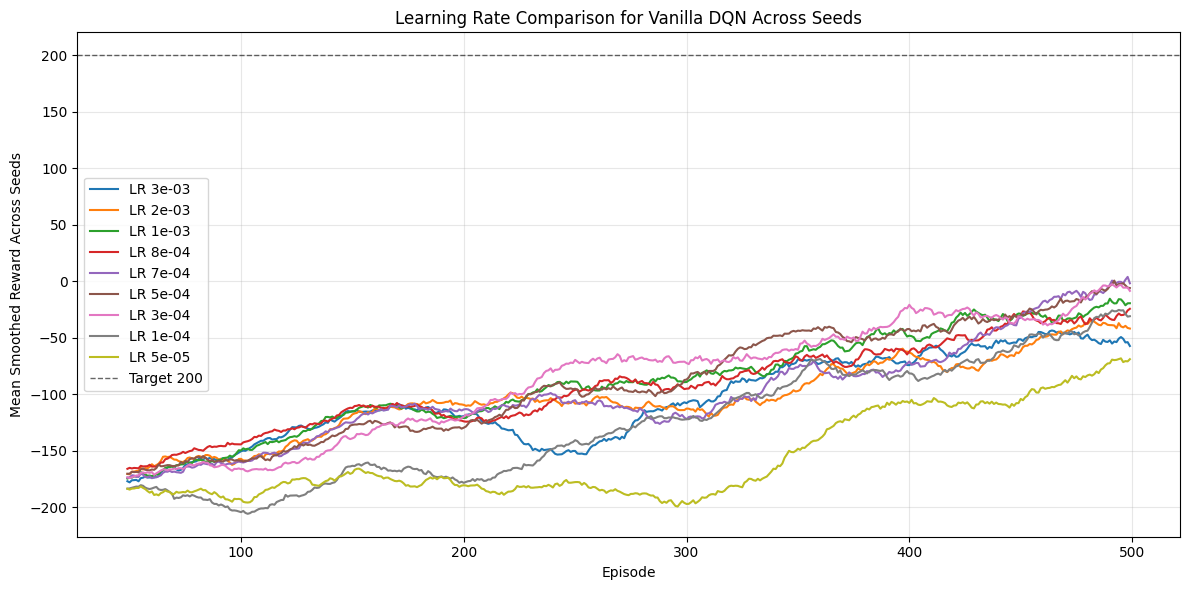

In [5]:
plt.figure(figsize=(12, 6))

for variant_name, result in all_results.items():
    # ======== Plot mean training curve across seeds ========
    rewards = result['train_rewards']
    window = min(50, max(1, len(rewards) // 2))
    if window > 1:
        smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')
        x_values = range(window - 1, window - 1 + len(smoothed))
        plt.plot(x_values, smoothed, label=f'LR {variant_name}')
    else:
        plt.plot(rewards, label=f'LR {variant_name}')
    # ======== End plot mean training curve across seeds ========

plt.axhline(y=200, color='black', linestyle='--', linewidth=1, alpha=0.6, label='Target 200')
plt.xlabel('Episode')
plt.ylabel('Mean Smoothed Reward Across Seeds')
plt.title('Learning Rate Comparison for Vanilla DQN Across Seeds')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 5.1 Visualization: Individual Learning Rate Training Curves

Each subplot shows the per-seed episode rewards with a mean smoothed reward curve for one learning rate. This makes it easier to inspect whether a setting improves consistently across seeds, recovers late, or relies on isolated lucky runs.



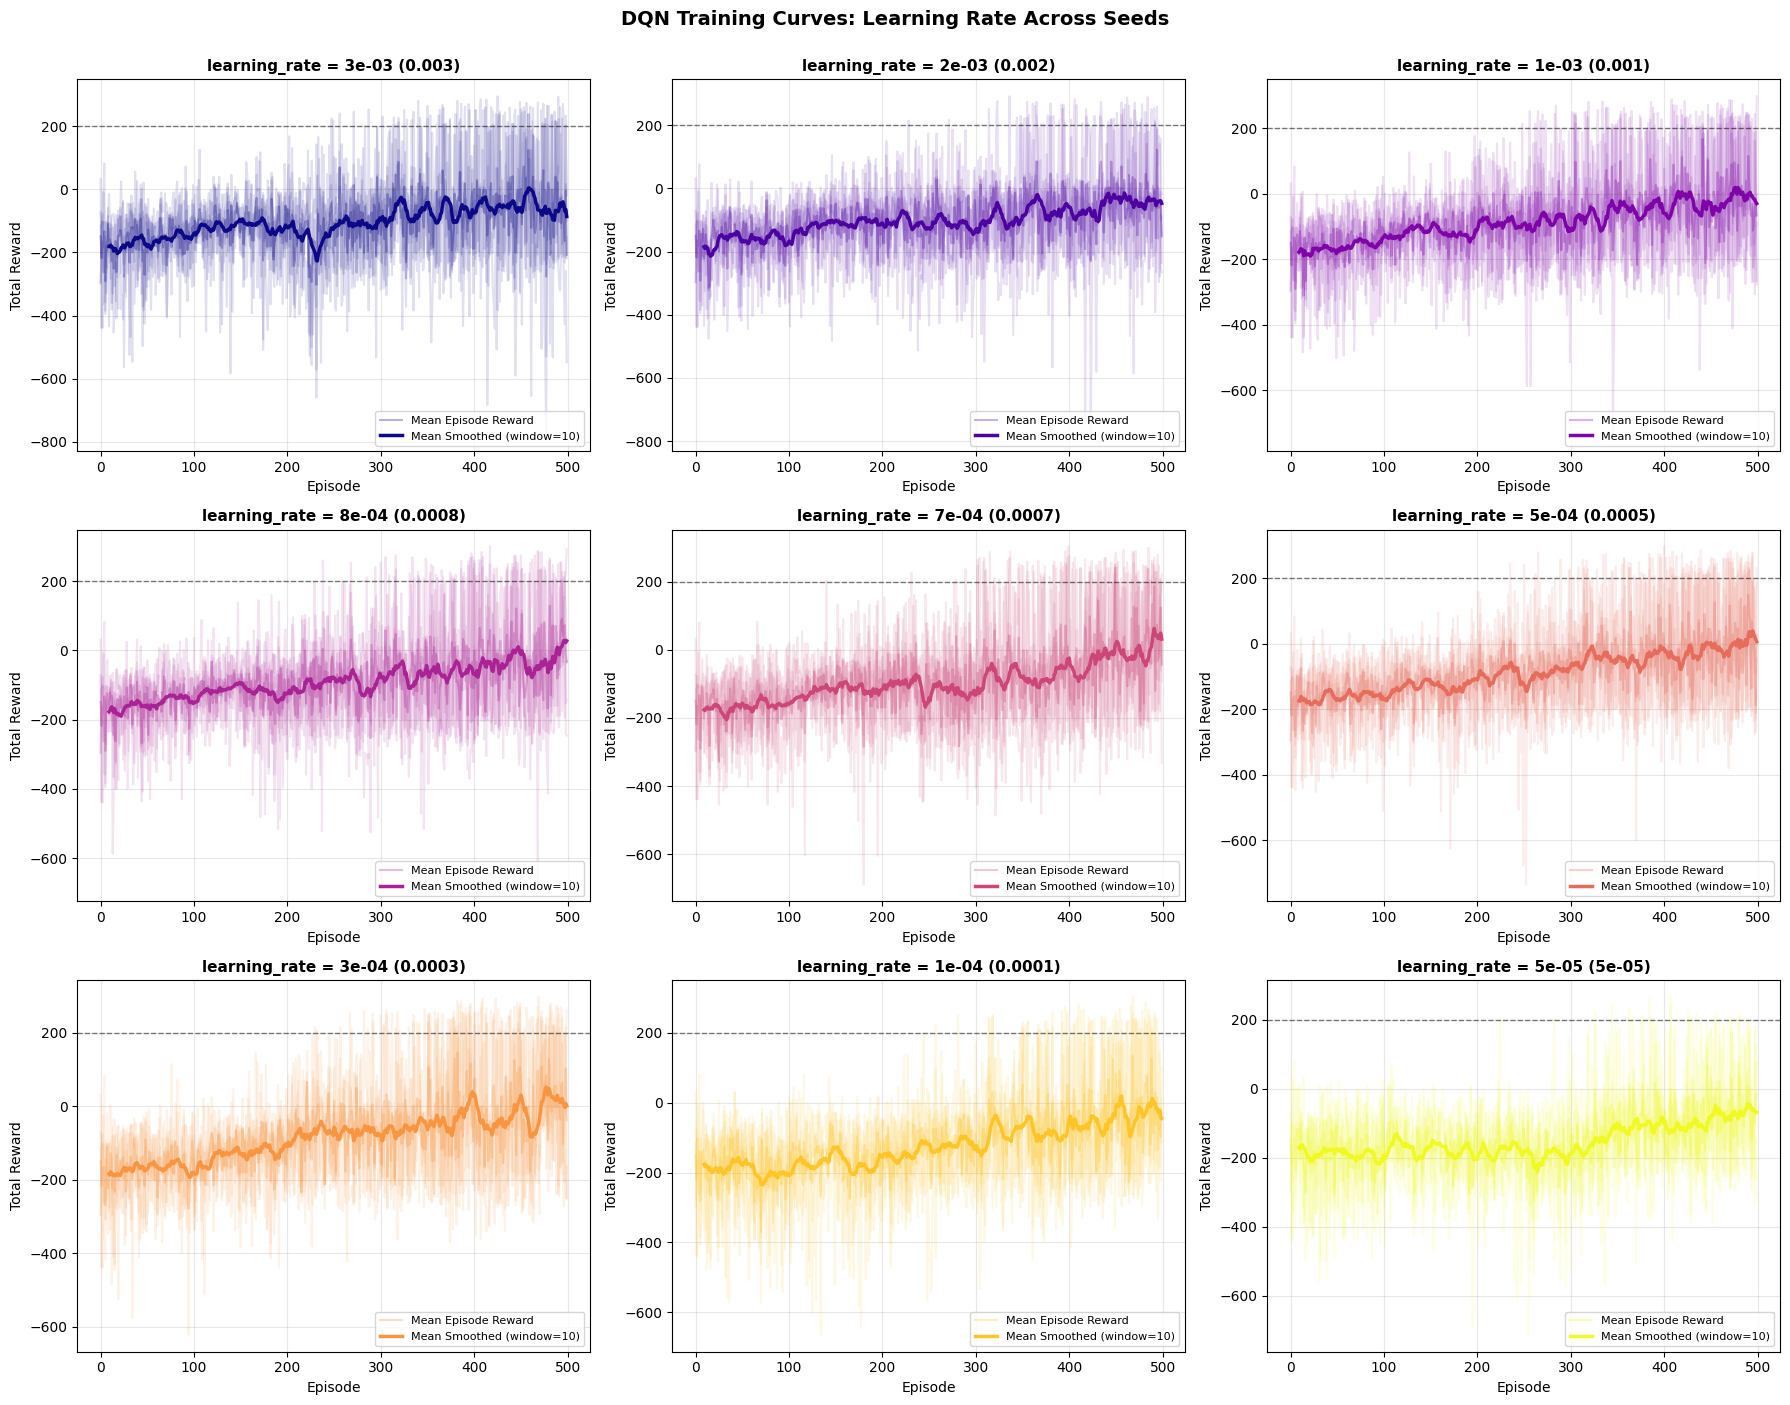

In [6]:
def format_lr_label(lr):
    return f'{lr:.0e} ({lr:g})'


def mean_curve(curves):
    curves = [np.asarray(curve, dtype=float) for curve in curves if len(curve) > 0]
    if not curves:
        return np.array([])
    min_len = min(len(curve) for curve in curves)
    return np.mean([curve[:min_len] for curve in curves], axis=0)


fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
colors = plt.cm.plasma(np.linspace(0, 1, len(summary_rows)))

# Plot from largest to smallest learning rate for easier visual comparison.
plot_rows = sorted(summary_rows, key=lambda row: row['learning_rate'], reverse=True)

for idx, row in enumerate(plot_rows):
    ax = axes[idx]
    variant_name = row['variant']
    result = all_results[variant_name]
    lr = result['learning_rate']
    color = colors[idx]
    window = 10

    seed_rewards = [run['train_rewards'] for run in result.get('runs', [])]
    for run in result.get('runs', []):
        ax.plot(run['train_rewards'], alpha=0.12, color=color)

    rewards = mean_curve(seed_rewards) if seed_rewards else np.asarray(result['train_rewards'])
    ax.plot(rewards, alpha=0.3, color=color, label='Mean Episode Reward')
    if len(rewards) >= window:
        smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')
        episodes = range(window - 1, window - 1 + len(smoothed))
        ax.plot(episodes, smoothed, linewidth=2.5, color=color, label=f'Mean Smoothed (window={window})')

    ax.axhline(y=200, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(f'learning_rate = {format_lr_label(lr)}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')

for empty_idx in range(len(plot_rows), len(axes)):
    axes[empty_idx].axis('off')

plt.suptitle('DQN Training Curves: Learning Rate Across Seeds', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()



## 5.2 Visualization: Final, Evaluation, and Peak Performance

This comparison separates late-stage training reward, post-training evaluation reward, and the best single training episode. Error bars show variation across seeds, which helps distinguish reliable performance from lucky trajectories.



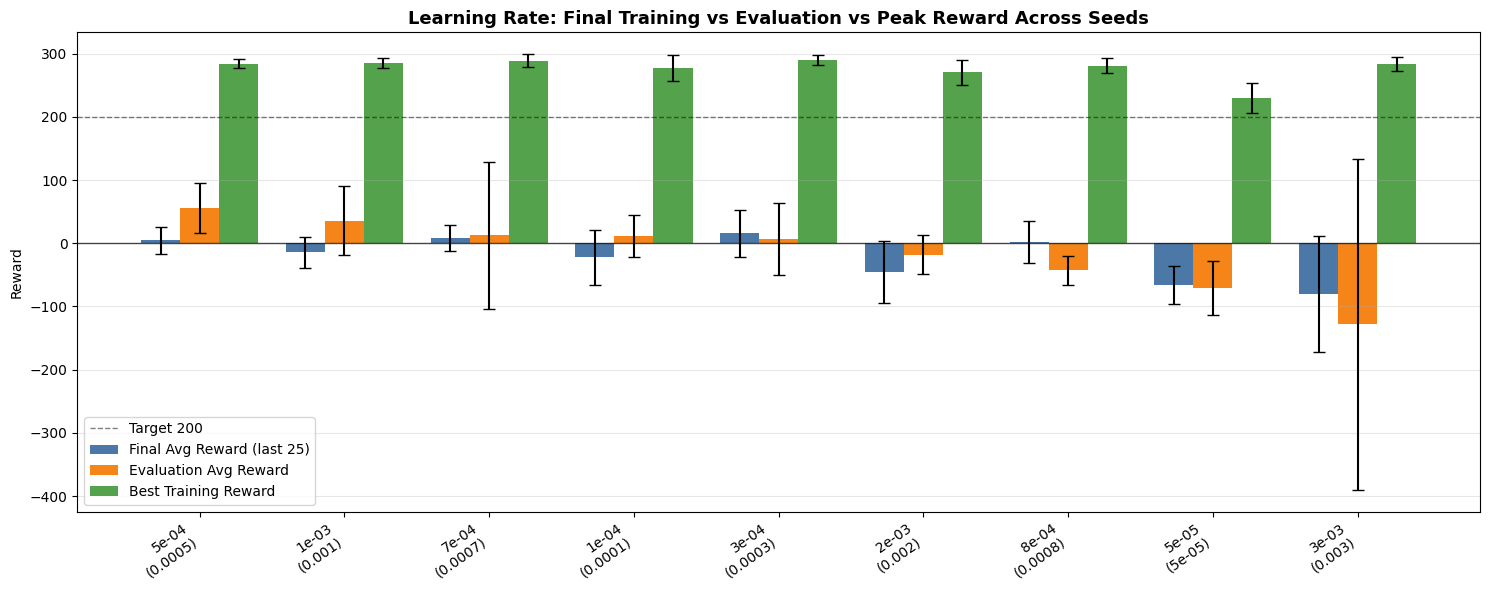

In [7]:
ordered_rows = sorted(summary_rows, key=lambda row: row['eval_avg_reward_mean'], reverse=True)
labels = [f"{row['variant']}\n({row['learning_rate']:g})" for row in ordered_rows]
final_avgs = [row['final_avg_reward_last_25_mean'] for row in ordered_rows]
final_stds = [row['final_avg_reward_last_25_std'] for row in ordered_rows]
eval_avgs = [row['eval_avg_reward_mean'] for row in ordered_rows]
eval_stds = [row['eval_avg_reward_std'] for row in ordered_rows]
best_rewards = [row['best_training_reward_mean'] for row in ordered_rows]
best_stds = [row['best_training_reward_std'] for row in ordered_rows]

x = np.arange(len(ordered_rows))
width = 0.27

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - width, final_avgs, width, yerr=final_stds, capsize=4, label='Final Avg Reward (last 25)', color='#4C78A8')
ax.bar(x, eval_avgs, width, yerr=eval_stds, capsize=4, label='Evaluation Avg Reward', color='#F58518')
ax.bar(x + width, best_rewards, width, yerr=best_stds, capsize=4, label='Best Training Reward', color='#54A24B')
ax.axhline(y=0, color='black', linewidth=1, alpha=0.7)
ax.axhline(y=200, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Target 200')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha='right')
ax.set_ylabel('Reward')
ax.set_title('Learning Rate: Final Training vs Evaluation vs Peak Reward Across Seeds', fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()




## 5.3 Visualization: Rewards and Loss Comparison

The following plots compare representative learning rates across both reward and loss. They highlight whether reward improvement is accompanied by stable value-function updates, or whether the policy only achieves isolated reward spikes.



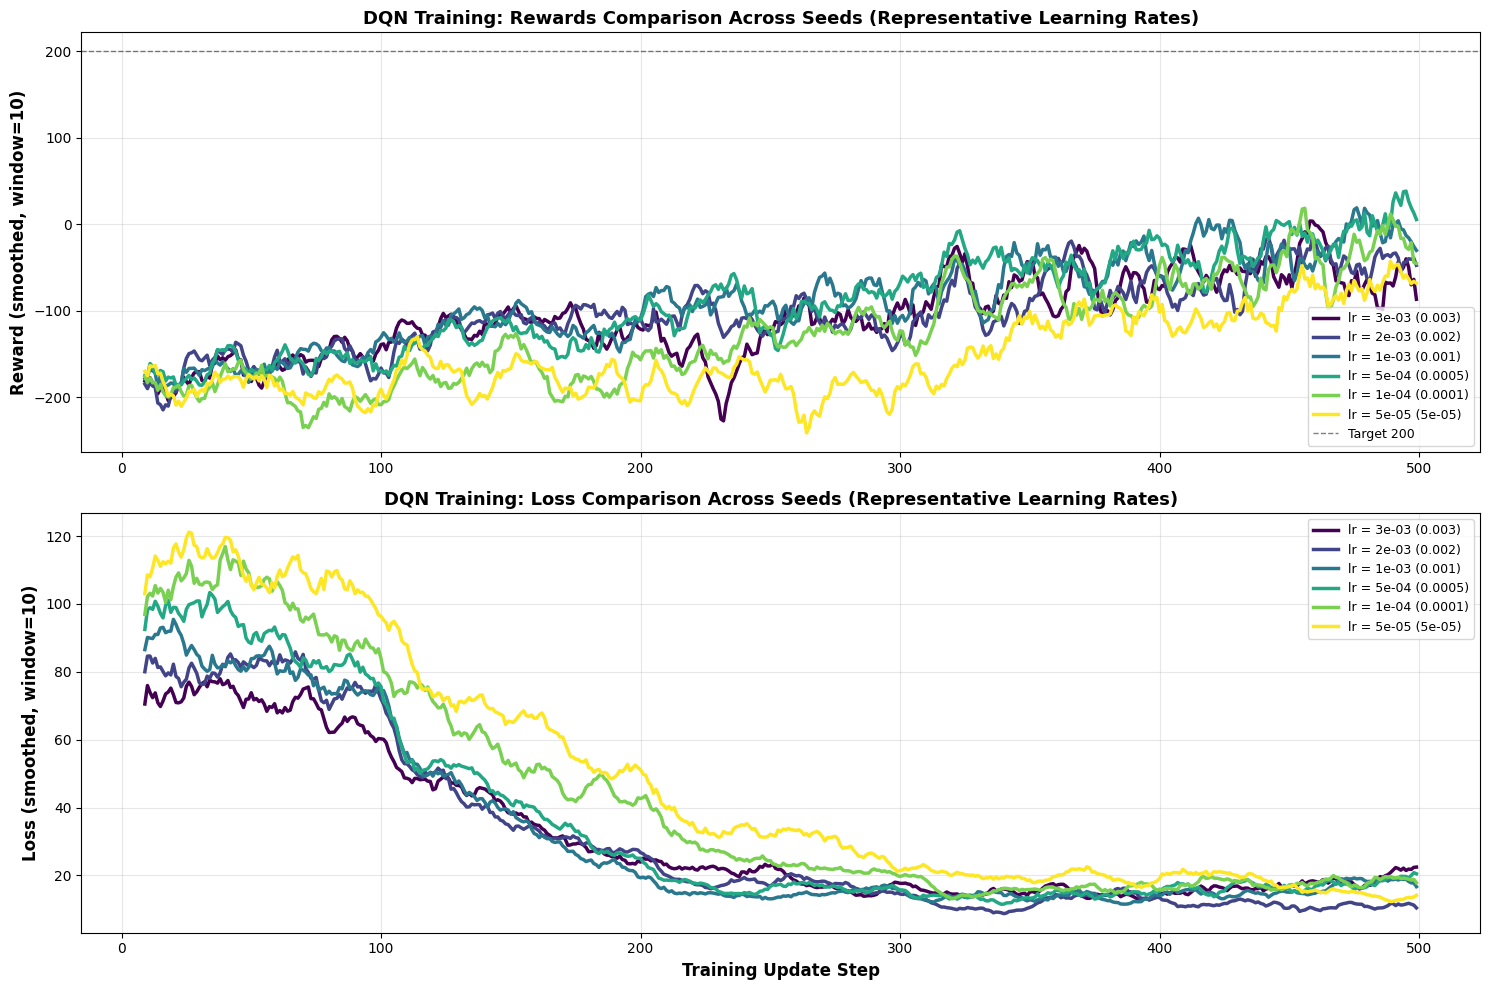

In [8]:
selected_variants = ['3e-03', '2e-03', '1e-03', '5e-04', '1e-04', '5e-05']
selected_variants = [variant for variant in selected_variants if variant in all_results]
colors = plt.cm.viridis(np.linspace(0, 1, len(selected_variants)))
window = 10

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=False)

for idx, variant_name in enumerate(selected_variants):
    result = all_results[variant_name]
    lr = result['learning_rate']
    label = f'lr = {format_lr_label(lr)}'
    color = colors[idx]

    rewards = mean_curve([run['train_rewards'] for run in result.get('runs', [])])
    if len(rewards) == 0:
        rewards = np.asarray(result.get('train_rewards', []), dtype=float)

    losses = mean_curve([run['losses'] for run in result.get('runs', [])])
    if len(losses) == 0:
        losses = np.asarray(result.get('losses', []), dtype=float)

    if len(rewards) >= window:
        smoothed_rewards = np.convolve(rewards, np.ones(window) / window, mode='valid')
        reward_episodes = range(window - 1, window - 1 + len(smoothed_rewards))
        ax1.plot(reward_episodes, smoothed_rewards, linewidth=2.5, color=color, label=label)
    elif len(rewards) > 0:
        ax1.plot(rewards, linewidth=2.5, color=color, label=label)

    if len(losses) >= window:
        smoothed_losses = np.convolve(losses, np.ones(window) / window, mode='valid')
        loss_steps = range(window - 1, window - 1 + len(smoothed_losses))
        ax2.plot(loss_steps, smoothed_losses, linewidth=2.5, color=color, label=label)
    elif len(losses) > 0:
        ax2.plot(losses, linewidth=2.5, color=color, label=label)

ax1.axhline(y=200, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Target 200')
ax1.set_ylabel(f'Reward (smoothed, window={window})', fontsize=12, fontweight='bold')
ax1.set_title('DQN Training: Rewards Comparison Across Seeds (Representative Learning Rates)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9, loc='lower right')

ax2.set_xlabel('Training Update Step', fontsize=12, fontweight='bold')
ax2.set_ylabel(f'Loss (smoothed, window={window})', fontsize=12, fontweight='bold')
ax2.set_title('DQN Training: Loss Comparison Across Seeds (Representative Learning Rates)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()



## 6. Summary and Analysis

This experiment tested nine learning rates for the vanilla DQN agent while keeping all other baseline settings fixed: 500 training episodes, batch size 32, two hidden layers, hidden dimension 128, epsilon decay 0.995, gamma 0.99, and five random seeds per learning rate. The tested learning rates were `3e-3 (0.003)`, `2e-3 (0.002)`, `1e-3 (0.001)`, `8e-4 (0.0008)`, `7e-4 (0.0007)`, `5e-4 (0.0005)`, `3e-4 (0.0003)`, `1e-4 (0.0001)`, and `5e-5 (0.00005)`.

### Summary Statistics

The table below is sorted by the final training average over the last 25 episodes, from best to worst. Based on the project guidance, this final 25-episode average is the primary training-stage indicator because it reflects late learning performance after the agent has had time to improve. The evaluation reward is then used as an additional learned-policy check to see whether late-stage training performance transfers to greedy evaluation episodes. The best single training reward is included only as a secondary diagnostic because it can reflect an isolated lucky trajectory. Standard deviations are included because the multi-seed results show substantial run-to-run variation.

|Learning Rate |Final Avg Reward (Last 25)|Evaluation Avg Reward |Best Training Reward |
|------:|------:|------:|------:|
| `3e-4 (0.0003)` |15.57 ± 36.92| 6.75 ± 56.32 | 289.58 ± 7.55 |
| `7e-4 (0.0007)` |8.64 ± 20.93| 12.54 ± 116.60 | 288.65 ± 10.43 |
| `5e-4 (0.0005)` |4.48 ± 21.66| 55.25 ± 39.57 | 283.85 ± 7.06 |
| `8e-4 (0.0008)` | 2.04 ± 33.63 | -43.07 ± 23.05 | 280.76 ± 11.62 |
| `1e-3 (0.001)` | -14.32 ± 24.31 | 35.95 ± 54.28 | 284.88 ± 8.48 |
| `1e-4 (0.0001)` | -22.42 ± 44.15 | 11.23 ± 33.34 | 276.85 ± 20.79 |
| `2e-3 (0.002)` | -45.15 ± 49.34 | -17.78 ± 30.24 | 270.37 ± 19.35 |
|`5e-5 (0.00005)` | -65.59 ± 30.36 | -70.89 ± 43.24 | 229.84 ± 24.34 |
| `3e-3 (0.003)` | -80.47 ± 92.12 | -128.03 ± 261.88 | 283.68 ± 10.88 |

### Interpreting the Training Curves

The individual training curves show that all learning rates remain noisy, which is expected in LunarLander because rewards depend heavily on landing trajectory and crash penalties. The multi-seed setting makes this clearer: several learning rates can produce strong individual episodes, but the final 25-episode average and standard deviation reveal whether late-stage learning is reliable. Evaluation reward is then used as a learned-policy check rather than as a replacement for the training-stage metric.

**Best final-25 training performance (`3e-4 (0.0003)`)**

- Using the final 25-episode average as the primary criterion, `3e-4 (0.0003)` is the best learning rate in this run. It achieved the highest late-stage training reward (`15.57 ±36.92`) and the highest mean best training reward (`289.58 ±7.55`). This suggests that, after training for 500 episodes, `3e-4` produced the strongest late-stage training behavior among the tested settings. However, its evaluation average was only slightly positive (`6.75 ±56.32`), so its learned greedy policy did not transfer as strongly to evaluation episodes as some alternatives.

**Strong late-stage alternatives (`7e-4 (0.0007)` and `5e-4 (0.0005)`)**

- `7e-4 (0.0007)` had the second-best final 25-episode average (`8.64 ±20.93`) and a high best training reward (`288.65 ±10.43`), making it a strong training-stage alternative. Its evaluation reward was positive (`12.54 ±116.60`), but the very large standard deviation indicates inconsistent learned-policy quality across seeds. 

- `5e-4 (0.0005)` ranked third by final 25-episode average (`4.48 ±21.66`), but it achieved the highest evaluation average (`55.25 ±39.57`). This makes `5e-4` the best setting from the evaluation perspective, even though it is not the best under the final-25 training metric.

**Evaluation-favorable but weaker final-25 behavior (`1e-3 (0.001)`)**

- `1e-3 (0.001)` is competitive when judged by evaluation reward, with the second-highest evaluation average (`35.95 ± 54.28`). However, its final 25-episode average is negative (`-14.32 ± 24.31`), so it is not the best choice under the main training-stage criterion. This suggests that `1e-3` can learn useful policies in some seeds but does not retain late-stage training performance as consistently as the stronger final-25 settings.

**Weak or unstable settings (`8e-4`, `1e-4`, `2e-3`, `5e-5`, and `3e-3`)**

- The remaining learning rates are weaker under the final 25-episode criterion. 
    - `8e-4 (0.0008)` was slightly positive in final training reward (`2.04 ±33.63`) but negative in evaluation (`-43.07 ±23.05`). 
    - `1e-4 (0.0001)`, `2e-3 (0.002)`, `5e-5 (0.00005)`, and `3e-3 (0.003)` all produced negative final 25-episode averages, meaning their late-stage training performance was poorer. 
    - The largest learning rate, `3e-3`, was especially unstable: it had the worst final 25-episode average (`-80.47 ±92.12`) and the worst evaluation average (`-128.03 ±261.88`). 
- This supports the idea that overly aggressive Q-value updates can produce brittle learning, while very small updates can learn too slowly within the 500-episode budget.

### Reward-Loss Relationship

The reward and loss comparison shows that loss behavior alone is not enough to select the best learning rate. Several settings can reduce TD error while still producing weak final-25 or evaluation returns. This is because the loss measures value-estimation error on replay samples, while the final 25-episode average and evaluation reward measure actual control performance. Therefore, the main selection should focus first on final 25-episode reward, then use evaluation reward, seed variability, and loss behavior as supporting evidence.

### Final Performance vs. Evaluation Performance

The final 25-episode average and evaluation reward answer related but different questions. The final 25-episode average is the best indicator of how well the agent was performing by the end of training, so it identifies `3e-4 (0.0003)` as the strongest learning rate under the main training-stage criterion. Evaluation reward tests the learned greedy policy after training, and under that criterion `5e-4 (0.0005)` performs best. This difference is important: `3e-4` shows the strongest late-stage training performance, while `5e-4` gives the strongest learned-policy evaluation result. The best interpretation is therefore not to replace one metric with the other, but to state clearly which conclusion follows from which metric.

### Conclusion

Based on the primary final 25-episode training metric, the best learning rate in this multi-seed run is `learning_rate = 3e-4 (0.0003)`, because it achieved the highest final training average over the last 25 episodes (`15.57 ±36.92`). This suggests that `3e-4` produced the strongest late-stage learning behavior within the 500-episode training budget.

As supporting evidence, the evaluation results show a slightly different picture: `5e-4 (0.0005)` achieved the highest evaluation reward (`55.25 ±39.57`), making it the best learned-policy evaluation setting. Therefore, the final recommendation is that `3e-4` is the best learning rate according to the main final-25 training criterion, while `5e-4` is a strong alternative if evaluation performance is prioritized. Very large learning rates (`2e-3` and `3e-3`) are less reliable, and the smallest learning rate (`5e-5`) appears too slow for the available training budget.

